# Breast Ultrasound Lesion Classification
## 01 — Image Preprocessing

### Objective

This notebook prepares the Breast Ultrasound Images (BUSI) dataset for downstream breast-lesion classification.

The final preprocessing pipeline used in the study consists of:

**Grayscale ultrasound image → Min–Max normalization → CLAHE → Resize to 224 × 224**

The purpose of preprocessing is to standardize image intensity and enhance local contrast while preserving lesion-related visual structure.

> **Research note:** Gaussian denoising was explored during development but was not retained in the final pipeline because it did not improve downstream classification performance. The final experiments therefore use normalization and CLAHE only.

### Dataset

The study uses the BUSI dataset, containing ultrasound images from three classes:

- `benign`
- `malignant`
- `normal`

The dataset itself is **not included in this repository**. See `data/README.md` for instructions on obtaining and placing the dataset locally.

## 1. Imports and Configuration

The paths below are deliberately configurable rather than tied to a particular computer. Before running the notebook, set `INPUT_ROOT` to the local directory containing `Dataset_BUSI_with_GT`.

The processed images are written to `preprocessed_dataset/` by default.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Project configuration
# -------------------------------------------------------------------

# Set this to the location of Dataset_BUSI_with_GT on your machine.
INPUT_ROOT = Path("../data/Dataset_BUSI_with_GT")

# Directory in which the preprocessed images will be saved.
OUTPUT_ROOT = Path("../data/preprocessed_dataset")

# Image size used by the downstream neural-network experiments.
TARGET_SIZE = (224, 224)

# BUSI classes present in the source dataset.
CLASSES = ["benign", "malignant", "normal"]

# CLAHE parameters used in the project.
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg"}

print(f"Input dataset:  {INPUT_ROOT.resolve()}")
print(f"Output dataset: {OUTPUT_ROOT.resolve()}")
print(f"Target size:    {TARGET_SIZE}")

Input dataset:  /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/archive/Dataset_BUSI_with_GT
Output dataset: /home/student25/Documents/REVIEW BLOCK/RB4/Computer_Vision/Group_Project/preprocessed_dataset
Target size:    (224, 224)


## 2. Dataset Structure

The expected source structure is:

```text
Dataset_BUSI_with_GT/
├── benign/
├── malignant/
└── normal/
```

The BUSI directories also contain ground-truth mask files. Mask files are **not** processed in this notebook; they are used later by the ROI-extraction workflow.

In [2]:
def count_images(root: Path) -> dict:
    """Count non-mask image files in each BUSI class directory."""
    counts = {}

    for cls in CLASSES:
        class_dir = root / cls

        if not class_dir.exists():
            counts[cls] = 0
            continue

        files = [
            p for p in class_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in SUPPORTED_EXTENSIONS
            and "_mask" not in p.stem.lower()
        ]
        counts[cls] = len(files)

    return counts


if INPUT_ROOT.exists():
    counts = count_images(INPUT_ROOT)
    print("Image counts:")
    for cls, count in counts.items():
        print(f"  {cls:10s}: {count}")
else:
    print(
        "INPUT_ROOT does not currently exist. "
        "Update the path above after downloading the dataset."
    )

Image counts:
  benign    : 437
  malignant : 210
  normal    : 133


## 3. Image Loading

Images are loaded as grayscale because the ultrasound data used in this study are analyzed as single-channel intensity images.

In [3]:
def load_image(image_path: Path) -> np.ndarray:
    """Load an image as a grayscale NumPy array."""
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    return image


def list_source_images(class_dir: Path):
    """Return image files while excluding BUSI ground-truth masks."""
    return sorted(
        p for p in class_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in SUPPORTED_EXTENSIONS
        and "_mask" not in p.stem.lower()
    )

## 4. Min–Max Normalization

For an image with minimum intensity $x_{min}$ and maximum intensity $x_{max}$, min–max normalization is:

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}+\epsilon}
$$

This maps pixel intensities to approximately $[0,1]$ and reduces variation caused by differences in image intensity scale.

In [4]:
def normalize_image(image: np.ndarray) -> np.ndarray:
    """Apply per-image min-max normalization to [0, 1]."""
    image = image.astype(np.float32)

    min_value = image.min()
    max_value = image.max()

    return (image - min_value) / (max_value - min_value + 1e-8)

## 5. Contrast Limited Adaptive Histogram Equalization (CLAHE)

CLAHE enhances local contrast by applying histogram equalization within local tiles while limiting contrast amplification.

The project uses:

- `clipLimit = 2.0`
- `tileGridSize = (8, 8)`

CLAHE is applied after normalization.

In [5]:
def apply_clahe(
    normalized_image: np.ndarray,
    clip_limit: float = CLAHE_CLIP_LIMIT,
    tile_grid_size: tuple = CLAHE_TILE_GRID_SIZE,
) -> np.ndarray:
    """Apply CLAHE to a normalized grayscale image and return [0, 1]."""
    image_uint8 = np.uint8(np.clip(normalized_image, 0, 1) * 255)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size,
    )

    enhanced = clahe.apply(image_uint8)

    return enhanced.astype(np.float32) / 255.0


def preprocess_ultrasound_image(
    image_path: Path,
    target_size: tuple = TARGET_SIZE,
) -> np.ndarray:
    """Load, normalize, enhance with CLAHE, and resize an ultrasound image."""
    image = load_image(image_path)
    image = normalize_image(image)
    image = apply_clahe(image)
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

    return image

## 6. Visual Inspection

Before processing the full dataset, inspect a representative image to verify the effect of normalization and CLAHE.

The example is selected deterministically rather than by an arbitrary directory index, making the notebook reproducible across systems.

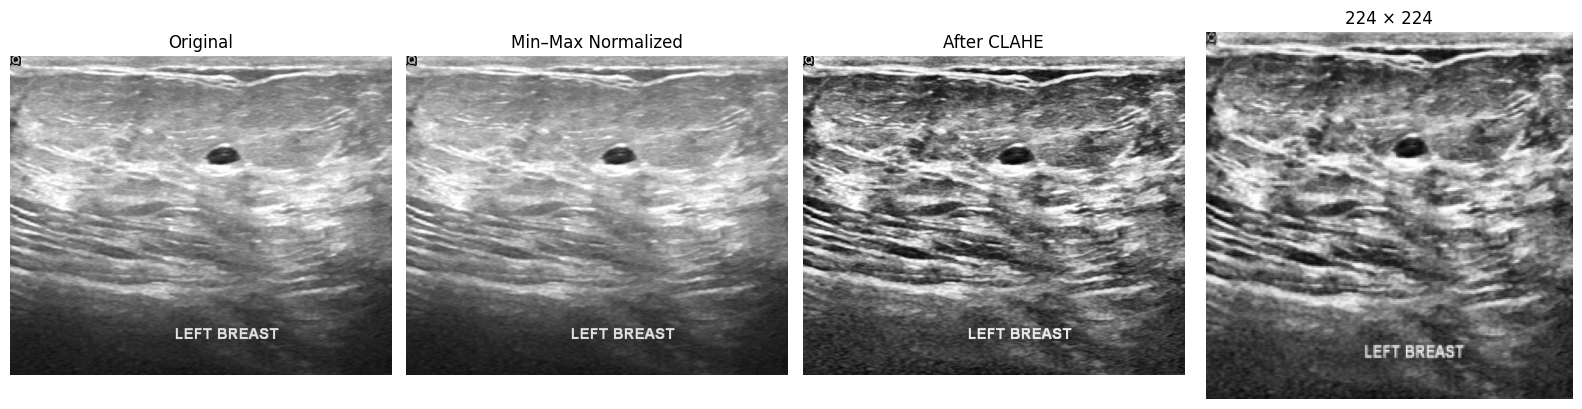

Example: benign (1).png


In [6]:
def choose_example_image(input_root: Path, class_name: str = "benign") -> Path:
    """Select the first valid non-mask image in a class directory."""
    image_files = list_source_images(input_root / class_name)

    if not image_files:
        raise FileNotFoundError(
            f"No valid images found in {input_root / class_name}"
        )

    return image_files[0]


if INPUT_ROOT.exists() and (INPUT_ROOT / "benign").exists():
    sample_path = choose_example_image(INPUT_ROOT, "benign")
    original = load_image(sample_path)
    normalized = normalize_image(original)
    clahe_image = apply_clahe(normalized)
    resized = cv2.resize(
        clahe_image, TARGET_SIZE, interpolation=cv2.INTER_AREA
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original")

    axes[1].imshow(normalized, cmap="gray")
    axes[1].set_title("Min–Max Normalized")

    axes[2].imshow(clahe_image, cmap="gray")
    axes[2].set_title("After CLAHE")

    axes[3].imshow(resized, cmap="gray")
    axes[3].set_title("224 × 224")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Example: {sample_path.name}")
else:
    print("Set INPUT_ROOT to visualize an example.")

## 7. Intensity Distribution Before and After CLAHE

The following comparison provides a simple visual check of the contrast enhancement effect.

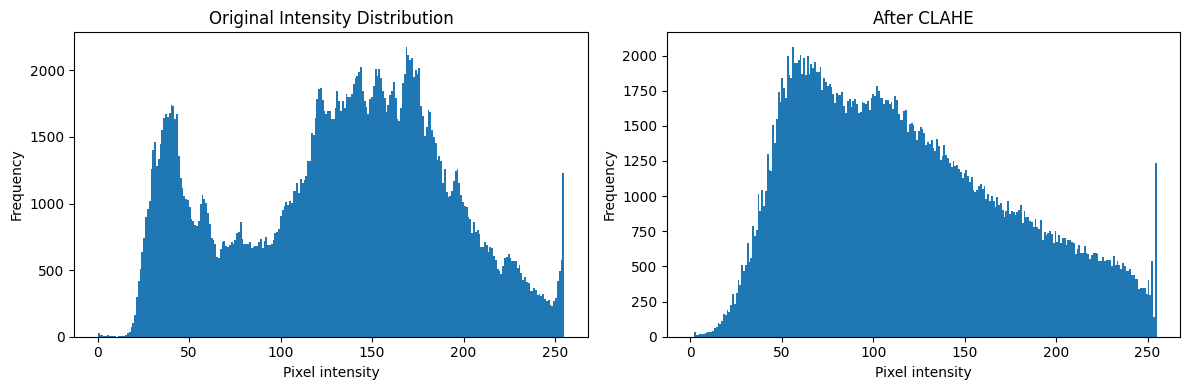

In [7]:
if INPUT_ROOT.exists() and (INPUT_ROOT / "benign").exists():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(original.ravel(), bins=256, range=(0, 255))
    axes[0].set_title("Original Intensity Distribution")
    axes[0].set_xlabel("Pixel intensity")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(np.uint8(clahe_image * 255).ravel(), bins=256, range=(0, 255))
    axes[1].set_title("After CLAHE")
    axes[1].set_xlabel("Pixel intensity")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()
else:
    print("Set INPUT_ROOT to generate the histogram comparison.")

## 8. Batch Preprocessing

The complete dataset is processed class-by-class.

For each non-mask image:

1. Load as grayscale.
2. Apply min–max normalization.
3. Apply CLAHE.
4. Resize to `224 × 224`.
5. Save as an 8-bit PNG.

Ground-truth mask files are skipped because they are required later for ROI extraction.

In [8]:
def preprocess_dataset(
    input_root: Path,
    output_root: Path,
    target_size: tuple = TARGET_SIZE,
) -> None:
    """Preprocess all non-mask BUSI images and save them to output_root."""
    if not input_root.exists():
        raise FileNotFoundError(
            f"Input dataset not found: {input_root.resolve()}"
        )

    for cls in CLASSES:
        input_dir = input_root / cls
        output_dir = output_root / cls

        if not input_dir.exists():
            raise FileNotFoundError(
                f"Expected class directory not found: {input_dir.resolve()}"
            )

        output_dir.mkdir(parents=True, exist_ok=True)

        image_files = list_source_images(input_dir)

        for image_path in image_files:
            processed = preprocess_ultrasound_image(
                image_path,
                target_size=target_size,
            )

            output_path = output_dir / image_path.name
            processed_uint8 = np.uint8(np.clip(processed, 0, 1) * 255)

            success = cv2.imwrite(str(output_path), processed_uint8)

            if not success:
                raise IOError(f"Could not save: {output_path}")

        print(f"Finished {cls}: {len(image_files)} images")


# Uncomment to run the full preprocessing pipeline:
#preprocess_dataset(INPUT_ROOT, OUTPUT_ROOT)

Finished benign: 437 images
Finished malignant: 210 images
Finished normal: 133 images


## 9. Verify the Processed Dataset

After running the batch-processing cell, this check confirms that the expected output directories and image dimensions were produced.

In [9]:
def verify_processed_dataset(output_root: Path) -> None:
    """Check output counts and image dimensions."""
    if not output_root.exists():
        print("Output directory does not exist yet.")
        return

    for cls in CLASSES:
        class_dir = output_root / cls
        files = list_source_images(class_dir) if class_dir.exists() else []

        dimensions = set()
        for path in files[:10]:
            image = load_image(path)
            dimensions.add(image.shape)

        print(
            f"{cls:10s}: {len(files)} images | "
            f"sample dimensions: {sorted(dimensions)}"
        )


# Uncomment after running preprocess_dataset:
#verify_processed_dataset(OUTPUT_ROOT)

benign    : 437 images | sample dimensions: [(224, 224)]
malignant : 210 images | sample dimensions: [(224, 224)]
normal    : 133 images | sample dimensions: [(224, 224)]


## 10. Research Note on Denoising

Gaussian denoising was considered during development because ultrasound images can contain speckle noise. However, the team evaluated denoising and found that it did not improve downstream classification performance.

Consequently, the final experimental preprocessing pipeline retained **min–max normalization + CLAHE**, without Gaussian denoising.

This notebook therefore documents the preprocessing actually used for the final experiments rather than an abandoned exploratory variant.

## Output

The resulting directory is:

```text
preprocessed_dataset/
├── benign/
├── malignant/
└── normal/
```

These processed images are used as the **Preprocessed Whole Image** condition in the downstream classification experiments.

The preprocessed images are also used as inputs to the ROI-extraction workflow to produce the **Preprocessed ROI** condition.

### Next notebook

**`02_roi_extraction.ipynb`** — extracts lesion-focused regions using the BUSI ground-truth masks.